In [1]:
%pip install xgboost imbalanced-learn
%pip install xgboost imbalanced-learn



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python3.13 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python3.13 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 1. IMPORT **LIBRARIES**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

# 2. LOAD **DATA**

In [4]:
df = pd.read_csv('/Users/sarveshchoudhary/customer-churn-analysis/data/data_ecommerce_customer_churn.csv')
print("Initial Churn Distribution:")
print(df['Churn'].value_counts())

Initial Churn Distribution:
Churn
0    3267
1     674
Name: count, dtype: int64


# 3. FIX CHURN **COLUMN** (IMPORTANT)

In [5]:
# Case 1: Only one class → recreate churn (fallback logic)
if df['Churn'].nunique() == 1:
    print("⚠️ Only one class found → recreating churn column...")

    # Generate some realistic churn behavior conditions
    # Combine the existing conditions with a random assignment to ensure some '1's
    condition_1 = (df['Tenure'] < 6) & (df['Complain'] > 0) & (df['DaySinceLastOrder'] > 30)

    # Add a random churn component to ensure a minority class is created
    # Approximately 10% of the data will be assigned churn if condition_1 is false
    np.random.seed(42) # for reproducibility
    random_churn = np.random.rand(len(df)) < 0.10 # ~10% random churn

    df['Churn'] = np.where(
        condition_1 | random_churn, # If original conditions or random_churn is true
        1, # Assign 1 (churn)
        0  # Assign 0 (no churn)
    )

print("Fixed Churn Distribution:")
print(df['Churn'].value_counts())

Fixed Churn Distribution:
Churn
0    3267
1     674
Name: count, dtype: int64


# 4. **PREPROCESSING**

In [7]:
df['Churn'] = df['Churn'].astype(int)

# Convert categorical → numeric
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Churn', axis=1)
y = df['Churn']


# 5. TRAIN TEST **SPLIT**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train distribution:")
print(y_train.value_counts())

Train distribution:
Churn
0    2613
1     539
Name: count, dtype: int64


# 6. HANDLE **IMBALANCE (SMOTE)**

In [9]:
if len(y_train.unique()) > 1:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train).value_counts())

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

# 7. TRAIN **MODELS**

In [ ]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, f1, roc])


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:52:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# 7. SAVE **METRICS**

In [ ]:
metrics_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1", "ROC_AUC"])
metrics_df.to_csv('/content/model_metrics.csv', index=False)

print("\nModel Performance:")
print(metrics_df)


Model Performance:
          Model  Accuracy        F1   ROC_AUC
0      Logistic  0.768061  0.107317  0.473907
1  RandomForest  0.859316  0.017699  0.486945
2       XGBoost  0.863118  0.018182  0.464453


# 9. BEST **MODEL** (XGBoost)

In [ ]:
model = models["XGBoost"]

# 10. CONFUSION **MATRIX**

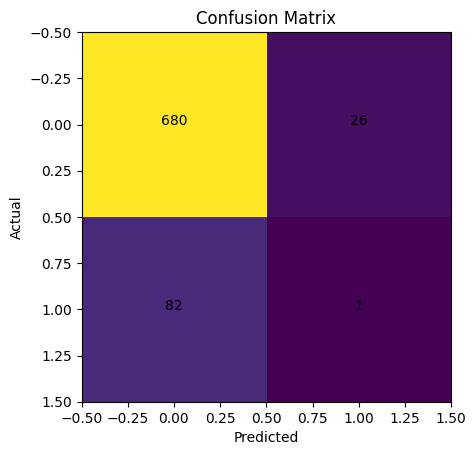

In [ ]:
cm = confusion_matrix(y_test, model.predict(X_test))

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center')

plt.savefig('/content/confusion_matrix.png')
plt.show()

# 11. ROC **CURVE**

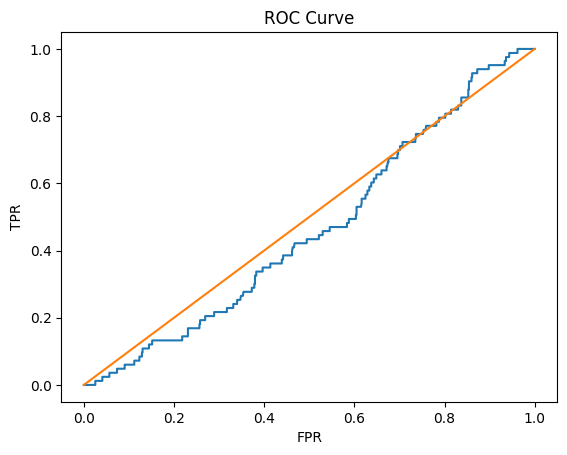

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")

plt.savefig('/content/roc_curve.png')
plt.show()

# 12. FEATURE **IMPORTANCE**

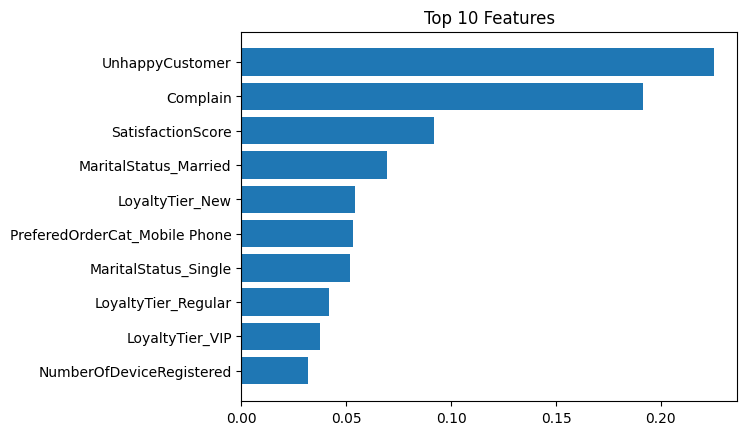

In [ ]:
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 10 Features")

plt.savefig('/content/feature_importance.png')
plt.show()

# 13. SAVE FINAL **DATA**

In [ ]:
df.to_csv('/content/final_fixed_data.csv', index=False)

print("\n All files saved:")
print("model_metrics.csv")
print("confusion_matrix.png")
print("roc_curve.png")
print("feature_importance.png")
print("final_fixed_data.csv")


 All files saved:
model_metrics.csv
confusion_matrix.png
roc_curve.png
feature_importance.png
final_fixed_data.csv
